In [1]:
import sys
import os
from datetime import datetime

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm
from scipy.linalg import inv

from joblib import Parallel, delayed

sys.path.insert(0, '../')
from codes.Quantum import *

from codes.Quantum import *
from codes.CSPSA import CSPSA
from ClassicalShadows import EnchancedShadowTomography

In [3]:
Rho = None
enhanced_shadows = None


gains = [3, 0, 0.1, 0.602, 0.101]
cspsa = CSPSA(gains=gains, minimize=False)


def complex2unitary( Z ):
    """
    Proyecta una matriz compleja arbitraria Z al grupo unitario U(4)
    mediante descomposición polar, U = Z (Z^dagger Z)^{-1/2}.
    """
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z


def random_unitary( dim, num=1 ):
    """
    Genera 'num' matrices unitarias aleatorias de dimensión 'dim'.
    """
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()


def maximally_entangled_state():
    """
    Estado singlete de dos qubits, (|01> - |10>)/sqrt(2), sin parámetro libre.
    """
    psi = np.array([0, 1, -1, 0]) / np.sqrt(2)
    return np.outer(psi, psi.conj())


def schmidt_state(a):
    """
    Estado puro de dos qubits en descomposición de Schmidt con parámetro
    a en [0, 0.5]. a = 0.5 recupera el estado maximamente entrelazado,
    a = 0 recupera el estado producto |00>.
    """
    psi = np.sqrt(1 - a) * np.array([1, 0, 0, 0]) \
        + np.sqrt(a) * np.array([0, 0, 0, 1])
    return np.outer(psi, psi.conj())


def werner_state(p):
    """
    Estado de Werner de dos qubits, mezcla convexa entre el estado singlete
    y el estado maximamente mixto, con parámetro de pureza p en [0, 1].
    p = 1 recupera el estado singlete puro, p = 0 el estado maximamente mixto.
    """
    rho_singlet = maximally_entangled_state()
    return p * rho_singlet + (1 - p) * np.eye(4) / 4


def build_network_state(rho_X, rho_Y, rho_Z):
    """
    Construye la matriz densidad conjunta de los seis qubits de la red
    triangular a partir de los estados de dos qubits (rho_X, rho_Y, rho_Z)
    distribuidos de forma independiente por las tres fuentes, reordenando
    los qubits para que cada detector reciba el par que le corresponde.
    """
    Rho = np.kron(np.kron(rho_X, rho_Y), rho_Z)
    permutation = [5, 0, 2, 1, 4, 3]
    order = permutation + [6 + q for q in permutation]
    Rho = Rho.reshape(12 * [2]).transpose(order).reshape(64, 64)
    return Rho


def create_shadow(Rho, N):
    """
    Entrena una sombra clasica de tamaño N a partir del estado Rho, y
    construye a partir de ella la reconstruccion Rho_hat que se usa como
    estado de referencia sigma en el estimador con variable de control.
    """
    shadow = EnchancedShadowTomography(6, N)
    shadow.train_shadows(Rho)
    Rho_hat = shadow.estimate_density_matrix()
    shadow.enhance_shadow(Rho_hat)
    return shadow, Rho_hat


def out_fun( Z, Rho=Rho ):
    """
    Evalua el funcional wagon-wheel de forma exacta, tal como se calcula
    en cspsa_triangle_shadows.ipynb, sin ninguna modificación en el cálculo.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Measures = triple_kron( Z[0], Z[1], Z[2] ) 
    probs  = np.sum( Measures.conj() * ( Rho @ Measures ), 
                        axis=0 ).reshape(6*[2]).real 
    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )
    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1] * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality 


def obj_fun( Z, enhanced_shadows=enhanced_shadows ):
    """
    Evalua el funcional wagon-wheel estimando cada termino con Classical
    Shadows en su version estandar (sin variable de control). Cálculo
    idéntico al de cspsa_triangle_shadows.ipynb.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)
    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality 


def obj_fun_enhanced( Z, enhanced_shadows=enhanced_shadows):
    """
    Igual a obj_fun, pero estimando cada termino con la correccion de
    variable de control (estimate_global_observable_enhanced). Cálculo
    idéntico al de cspsa_triangle_shadows.ipynb.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable_enhanced( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable_enhanced( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)
    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality

from joblib import Parallel, delayed

def run_simulation(Rho, N_rep, max_iter, N_shadow, nombre_archivo,
                    carpeta=".", n_jobs=-1):
    """
    Corre el protocolo completo de optimizacion (Tomo, Shadow, EnhShadow)
    sobre el estado Rho entregado, durante N_rep repeticiones independientes
    de max_iter iteraciones cada una, reentrenando una sombra de N_shadow
    mediciones en cada repeticion. Las repeticiones se paralelizan con
    joblib, y cada una reinicializa su semilla aleatoria para asegurar
    independencia entre procesos.

    Guarda en carpeta/nombre_archivo, imitando el formato de
    Tesis_Schmidt.ipynb, el arreglo crudo de cada nivel de evaluacion
    (Out1, Out2, Out3) junto con su mean, median, q1 y q3 por iteracion,
    mas metadatos (N_rep, max_iter, N_shadow).
    """
    def run_one(idx):
        np.random.seed()
        print(idx)

        enhanced_shadows, Rho_hat = create_shadow(Rho, N_shadow)

        obj_fun_tomo = lambda Z: out_fun(Z, Rho_hat)
        obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
        obj_fun_enha = lambda Z: obj_fun_enhanced(Z, enhanced_shadows)

        Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])

        results1 = cspsa.minimize(obj_fun_tomo, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_tomo)
        results2 = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_shad)
        results3 = cspsa.minimize(obj_fun_enha, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_enha)

        return results1.fun, results2.fun, results3.fun

    resultados = Parallel(n_jobs=n_jobs)(
        delayed(run_one)(idx) for idx in range(N_rep)
    )
    resultados = np.array(resultados)

    Out1 = resultados[:, 0]
    Out2 = resultados[:, 1]
    Out3 = resultados[:, 2]

    os.makedirs(carpeta, exist_ok=True)
    ruta = os.path.join(carpeta, nombre_archivo)

    np.savez(ruta,
             Out1=Out1, Out2=Out2, Out3=Out3,
             mean1=Out1.mean(axis=0), median1=np.median(Out1, axis=0),
             q1_1=np.percentile(Out1, 25, axis=0), q3_1=np.percentile(Out1, 75, axis=0),
             mean2=Out2.mean(axis=0), median2=np.median(Out2, axis=0),
             q1_2=np.percentile(Out2, 25, axis=0), q3_2=np.percentile(Out2, 75, axis=0),
             mean3=Out3.mean(axis=0), median3=np.median(Out3, axis=0),
             q1_3=np.percentile(Out3, 25, axis=0), q3_3=np.percentile(Out3, 75, axis=0),
             N_rep=N_rep, max_iter=max_iter, N_shadow=N_shadow)

    print(f"  Guardado: {ruta}")

    return Out1, Out2, Out3

In [4]:
def cargar_npz(carpeta, nombre_archivo):
    """
    Carga el archivo .npz correspondiente a una simulacion, ubicado en
    carpeta/nombre_archivo.
    """
    return np.load(os.path.join(carpeta, nombre_archivo))

# Simulación 01

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Estado maximalmente entrelazado, singlete $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, sin parámetro libre |
| $N$ (mediciones por sombra) | $10000$, sombra reentrenada en cada repetición |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** primer escenario de la serie, usado como caso base de
referencia, en el que las tres fuentes de la red triangular distribuyen
el mismo estado maximalmente entrelazado, sin parámetro libre. Se
comparan tres niveles de evaluación del funcional wagon-wheel a lo largo
de las iteraciones, la reconstrucción tomográfica obtenida a partir de
la sombra (`Out1`), la estimación directa con Classical Shadows en su
versión estándar (`Out2`), y la variante con corrección de variable de
control (`Out3`), las tres calculadas sobre la misma sombra entrenada en
cada repetición.

**Archivos generados:** `Simulacion_01/Sim01.npz`, con el arreglo crudo
de cada nivel (`Out1`, `Out2`, `Out3`, de tamaño `max_rep` x `max_iter`)
junto con `mean`, `median`, `q1` y `q3` por iteración para cada uno
(`mean1`/`median1`/`q1_1`/`q3_1`, y así para 2 y 3).

In [13]:
Rho_max = build_network_state(*3 * [maximally_entangled_state()])

#Out1, Out2, Out3 = run_simulation(
#    Rho_max,
#    N_rep=100,
#    max_iter=1000,
#    N_shadow=100000,
#    nombre_archivo="Sim01.npz",
#    carpeta="Simulacion_01"
#)

## Gráfico Simulación 01 — Convergencia de la mediana

Muestra la mediana de $I_{\rm w-w}$ a lo largo de las `max_iter`
iteraciones para los tres niveles de evaluación (Tomo, Shadow,
EnhShadow), junto con la cota clásica ($I_{\rm w-w}=0$) y el máximo
cuántico $(\sqrt{2}-1)/16$, para el estado maximalmente entrelazado.

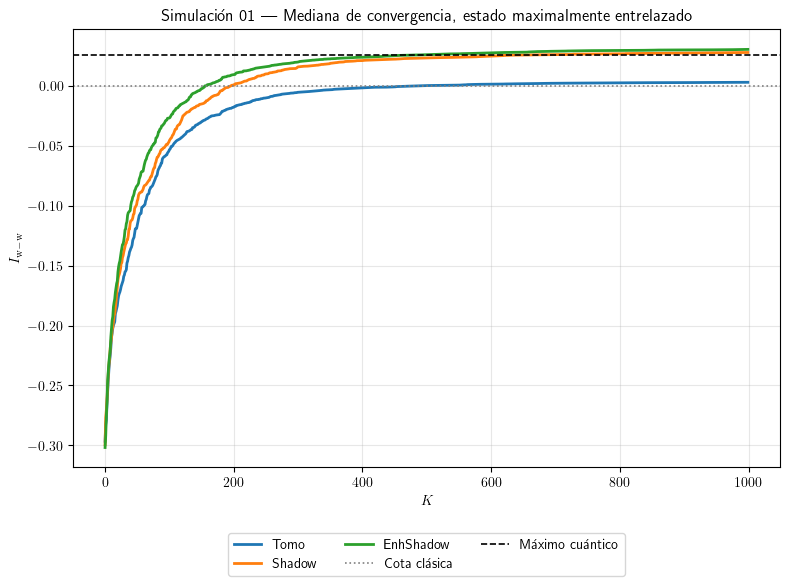

In [14]:
Data = cargar_npz("Simulacion_01", "Sim01.npz")
it = np.arange(len(Data['median1']))
valor_cuantico = (np.sqrt(2) - 1) / 16

plt.figure(figsize=(8, 6))
plt.plot(it, Data['median1'], label="Tomo", linewidth=2)
plt.plot(it, Data['median2'], label="Shadow", linewidth=2)
plt.plot(it, Data['median3'], label="EnhShadow", linewidth=2)
plt.axhline(0, color='gray', linestyle=':', linewidth=1.2, label="Cota clásica")
plt.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2, label="Máximo cuántico")
plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Simulación 01 --- Mediana de convergencia, estado maximalmente entrelazado")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_3maxent_med.pdf")
plt.savefig("Simulacion_01/Sim01_3maxent_med.png", dpi=600)
plt.show()

## Simulación 01_02 — Barrido en número de shadows

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Estado maximalmente entrelazado, singlete $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, fijo, sin parámetro libre |
| $N_{\rm sh}$ (mediciones por sombra) | $\{10^3,\ 10^4,\ 10^5,\ 10^6\}$, sombra reentrenada en cada repetición |
| `N_rep` | 100 |
| $N_{\rm it}$ (iteraciones de CSPSA) | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |
| Nivel de evaluación | Solo Shadow (`obj_fun`), sin Tomo ni EnhShadow |

**Descripción:** experimento dentro de Simulación 01, distinto del caso
base ya guardado en `Sim01.npz`, en el que se fija el estado
maximalmente entrelazado en las tres fuentes y se varía únicamente el
número de mediciones de la sombra, $N_{\rm sh}$, empleado para
entrenarla en cada repetición. A diferencia del resto de las
simulaciones, aquí solo se evalúa el funcional wagon-wheel mediante
Classical Shadows en su versión estándar, sin la reconstrucción
tomográfica (Tomo) ni la corrección de variable de control (EnhShadow),
ya que el objetivo es aislar el efecto de $N_{\rm sh}$ sobre este único
estimador, a lo largo de las $N_{\rm it}$ iteraciones de CSPSA.

**Convención de nombres:** los valores de $N_{\rm sh}$ se escriben en
notación exponencial corta, `N1e3`, `N1e4`, `N1e5`, `N1e6`, donde `1e3`
denota $1\times10^3=1000$. No se usa la notación `10e3`, que en
notación científica estándar significa $10\times10^3=10000$.

**Archivos generados:** `Simulacion_01/Sim01_02_N1e3.npz`,
`Simulacion_01/Sim01_02_N1e4.npz`, `Simulacion_01/Sim01_02_N1e5.npz`,
`Simulacion_01/Sim01_02_N1e6.npz`, cada uno con `Out2` (arreglo crudo,
de tamaño `N_rep` x $N_{\rm it}$, del nivel Shadow) junto con `mean2`,
`median2`, `q1_2` y `q3_2` por iteración.

## Función `run_shadow_only_N_grid`

Corre únicamente el nivel Shadow (`obj_fun`, sin Tomo ni EnhShadow) para
el estado maximalmente entrelazado fijo, variando el número de
mediciones $N$ de la sombra según una lista de valores, con `N_rep`
repeticiones independientes paralelizadas por cada valor de $N$. Guarda
un archivo `.npz` por valor de $N$, usando la convención `N1e{exponente}`.

In [15]:
def run_shadow_only_N_grid(Rho, valores_N_sh, prefijo, carpeta="Simulacion_01",
                            N_rep=100, max_iter=1000, n_jobs=-3):
    """
    Corre unicamente el nivel Shadow (obj_fun, sin Tomo ni EnhShadow) para
    el estado Rho fijo, variando el numero de mediciones de la sombra,
    N_sh, segun valores_N_sh, con N_rep repeticiones independientes
    paralelizadas por cada valor de N_sh, cada una de max_iter (N_it)
    iteraciones de CSPSA. Guarda un archivo .npz por valor de N_sh.
    """
    resultados = {}
    for N_sh in valores_N_sh:
        exponente = round(np.log10(N_sh))
        print(f"=== {prefijo}, N_sh = 1e{exponente} ===")

        def run_one(idx):
            np.random.seed()
            enhanced_shadows, Rho_hat = create_shadow(Rho, N_sh)
            obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
            Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
            results2 = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                       postprocessing=complex2unitary,
                                       output_function=obj_fun_shad)
            return results2.fun

        Out2 = np.array(Parallel(n_jobs=n_jobs)(delayed(run_one)(idx) for idx in range(N_rep)))

        os.makedirs(carpeta, exist_ok=True)
        nombre_archivo = f"{prefijo}_N1e{exponente}.npz"
        ruta = os.path.join(carpeta, nombre_archivo)

        np.savez(ruta,
                 Out2=Out2,
                 mean2=Out2.mean(axis=0), median2=np.median(Out2, axis=0),
                 q1_2=np.percentile(Out2, 25, axis=0), q3_2=np.percentile(Out2, 75, axis=0),
                 N_rep=N_rep, N_it=max_iter, N_sh=N_sh)

        print(f"  Guardado: {ruta}")
        resultados[N_sh] = Out2

    return resultados

In [17]:
valores_N_sh = [1e3, 1e4, 1e5, 1e6]

#resultados_sim01_02 = run_shadow_only_N_grid(
#    Rho_max, valores_N_sh, "Sim01_02", carpeta="Simulacion_01"
#)

In [19]:
import glob
import re

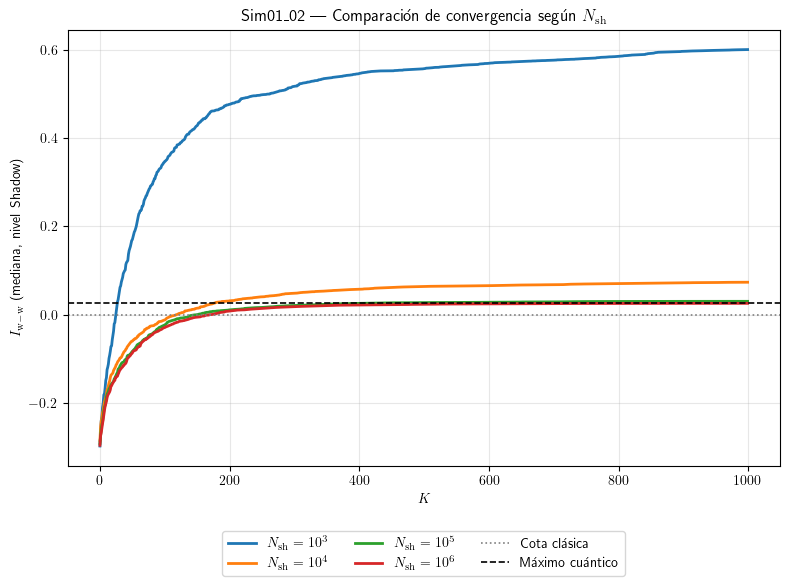

In [20]:
patron = os.path.join("Simulacion_01", "Sim01_02_N1e*.npz")
archivos = sorted(glob.glob(patron),
                   key=lambda f: int(re.search(r"N1e(\d+)", f).group(1)))

valor_cuantico = (np.sqrt(2) - 1) / 16

plt.figure(figsize=(8, 6))
for ruta in archivos:
    exponente = int(re.search(r"N1e(\d+)", ruta).group(1))
    Data = np.load(ruta)
    it = np.arange(len(Data['median2']))
    plt.plot(it, Data['median2'], linewidth=2,
             label=rf"$N_{{\rm sh}}=10^{exponente}$")

plt.axhline(0, color='gray', linestyle=':', linewidth=1.2, label="Cota clásica")
plt.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2, label="Máximo cuántico")
plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$ (mediana, nivel Shadow)")
plt.title(r"Sim01\_02 --- Comparación de convergencia según $N_{\rm sh}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_02_comparacion.pdf")
plt.show()

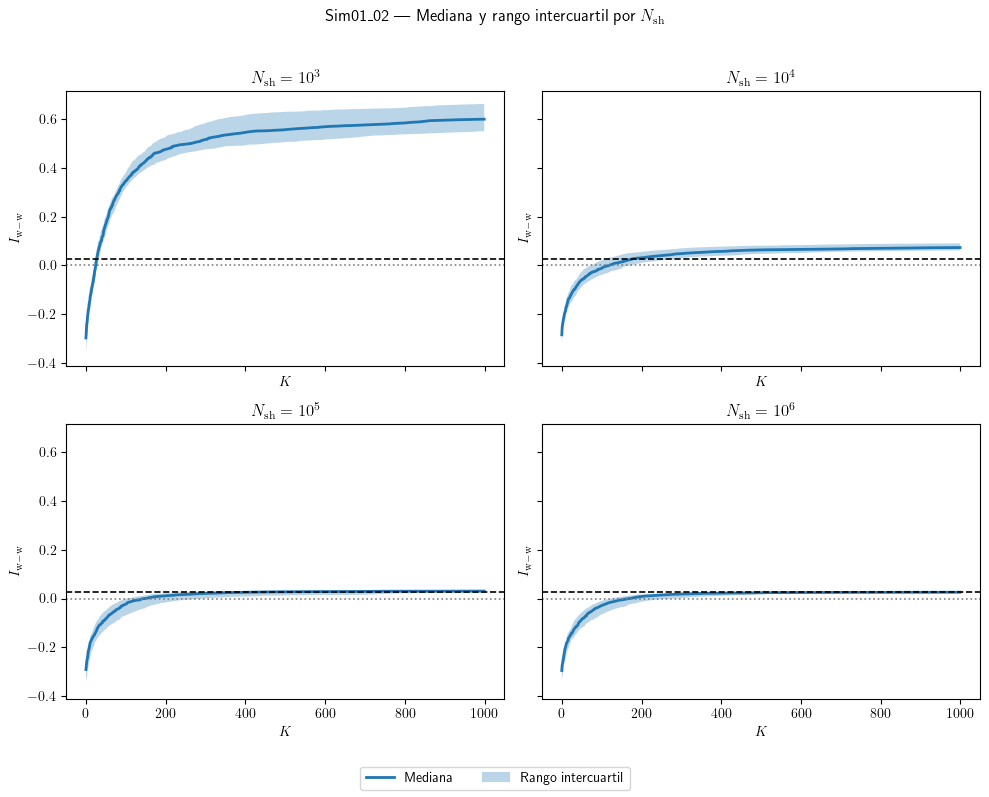

In [21]:
patron = os.path.join("Simulacion_01", "Sim01_02_N1e*.npz")
archivos = sorted(glob.glob(patron),
                   key=lambda f: int(re.search(r"N1e(\d+)", f).group(1)))

valor_cuantico = (np.sqrt(2) - 1) / 16

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, ruta in zip(axes, archivos):
    exponente = int(re.search(r"N1e(\d+)", ruta).group(1))
    Data = np.load(ruta)
    it = np.arange(len(Data['median2']))
    ax.plot(it, Data['median2'], linewidth=2, label="Mediana")
    ax.fill_between(it, Data['q1_2'], Data['q3_2'], alpha=0.3, label="Rango intercuartil")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponente}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
fig.suptitle(r"Sim01\_02 --- Mediana y rango intercuartil por $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig("Simulacion_01/Sim01_02_mediana_iqr.pdf")
plt.show()

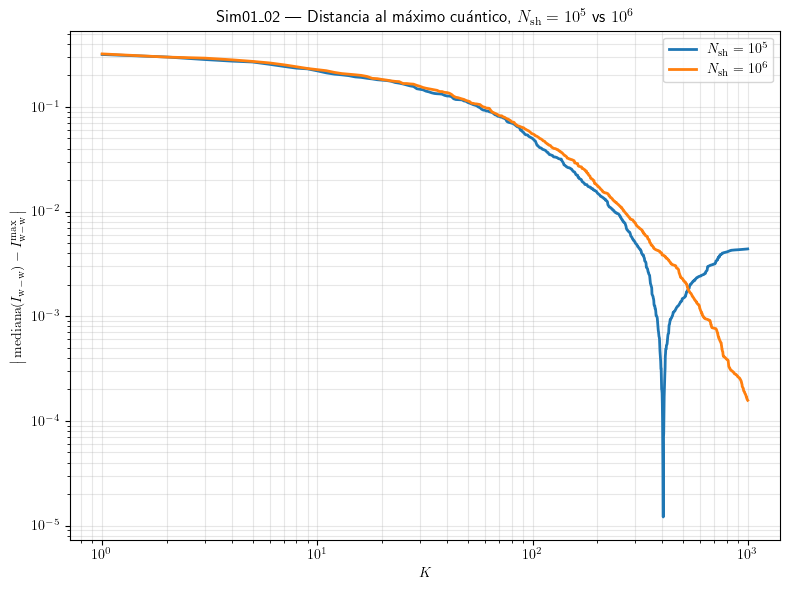

In [27]:
valor_cuantico = (np.sqrt(2) - 1) / 16

plt.figure(figsize=(8, 6))

for exponente in [5, 6]:
    ruta = f"Simulacion_01/Sim01_02_N1e{exponente}.npz"
    Data = np.load(ruta)
    median2, q1_2, q3_2 = Data['median2'], Data['q1_2'], Data['q3_2']

    dist_mediana = np.clip(np.abs(median2 - valor_cuantico), piso, None)
    dist_q1 = np.clip(np.abs(q1_2 - valor_cuantico), piso, None)
    dist_q3 = np.clip(np.abs(q3_2 - valor_cuantico), piso, None)

    # el valor absoluto puede invertir cual de los dos, q1 o q3, queda
    # mas cerca o mas lejos del maximo cuantico, asi que la banda se
    # arma con el minimo y el maximo punto a punto, no q1 y q3 directo
    banda_inf = np.minimum(dist_q1, dist_q3)
    banda_sup = np.maximum(dist_q1, dist_q3)

    it = np.arange(1, len(dist_mediana) + 1)  # empieza en 1, log(0) no esta definido

    linea, = plt.plot(it, dist_mediana, linewidth=2,
                       label=rf"$N_{{\rm sh}}=10^{exponente}$")
    #plt.fill_between(it, banda_inf, banda_sup, alpha=0.25, color=linea.get_color())

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$K$")
plt.ylabel(r"$\left|\,\mathrm{mediana}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")
plt.title(r"Sim01\_02 --- Distancia al máximo cuántico, $N_{\rm sh}=10^5$ vs $10^6$")
plt.legend(loc='upper right')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_02_distancia_cuantico.pdf")
plt.show()

## Simulación 01_03 — Evaluación exacta y Shadow, barrido en $N_{\rm sh}$

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Estado maximalmente entrelazado, singlete $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, fijo, sin parámetro libre |
| $N_{\rm sh}$ (mediciones por sombra) | $\{10^3,\ 10^4,\ 10^5,\ 10^6\}$, sombra reentrenada en cada repetición |
| `N_rep` | 100 |
| $N_{\rm it}$ (iteraciones de CSPSA) | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |
| Niveles de evaluación | Exacta (`out_fun` sobre el estado verdadero $\rho$) y Shadow (`obj_fun`) |

**Descripción:** continuación de Sim01_02, sobre el mismo barrido de
$N_{\rm sh}\in\{10^3,10^4,10^5,10^6\}$ y el mismo estado maximalmente
entrelazado fijo. Para cada valor de $N_{\rm sh}$ se corren dos
optimizaciones independientes, una guiada y evaluada por `out_fun`
sobre el estado verdadero $\rho$ (evaluación exacta), y otra guiada y
evaluada por `obj_fun` (Shadow), cada una con su propia semilla
aleatoria. La evaluación exacta no depende realmente de $N_{\rm sh}$,
ya que no usa la sombra, así que sus cuatro repeticiones por archivo
son estadísticamente equivalentes entre sí, no una función de
$N_{\rm sh}$; se guardan de todas formas dentro de cada archivo para
tener siempre a mano la referencia exacta junto a su Shadow
correspondiente.

**Convención de nombres:** igual que en Sim01_02, los valores de
$N_{\rm sh}$ se escriben en notación exponencial corta, `N1e3`, `N1e4`,
`N1e5`, `N1e6`.

**Archivos generados:** `Simulacion_01/Sim01_03_N1e3.npz`,
`Simulacion_01/Sim01_03_N1e4.npz`, `Simulacion_01/Sim01_03_N1e5.npz`,
`Simulacion_01/Sim01_03_N1e6.npz`, cada uno con `Out_ex` (evaluación
exacta) y `Out_sh` (Shadow), de tamaño `N_rep` x $N_{\rm it}$ cada uno,
junto con `mean`, `median`, `q1` y `q3` por iteración para ambos
(`mean_ex`/`median_ex`/`q1_ex`/`q3_ex`, y lo mismo con sufijo `_sh`),
nombrados así para que no se confundan con `Out1`/`Out2` de `Sim01.npz`,
donde `Out1` corresponde a Tomo (evaluación exacta sobre $\hat\rho$),
no a la evaluación exacta sobre $\rho$ que se guarda aquí.

## Función `run_exact_shadow_N_grid`

Para cada valor de $N_{\rm sh}$, corre dos optimizaciones independientes
de `N_rep` repeticiones cada una, paralelizadas con `joblib`, una guiada
por `out_fun` sobre el estado verdadero $\rho$ (evaluación exacta), y
otra guiada por `obj_fun` sobre una sombra entrenada con $N_{\rm sh}$
mediciones (Shadow). Guarda ambos resultados, `Out_ex` y `Out_sh`, en un
mismo archivo `.npz` por valor de $N_{\rm sh}$.

In [28]:
def run_exact_shadow_N_grid(Rho, valores_N_sh, prefijo, carpeta="Simulacion_01",
                             N_rep=100, max_iter=1000, n_jobs=-1):
    """
    Para cada valor de N_sh en valores_N_sh, corre dos optimizaciones
    independientes de N_rep repeticiones cada una, paralelizadas con
    joblib: una guiada por out_fun sobre el estado verdadero Rho
    (evaluacion exacta, Out_ex), y otra guiada por obj_fun sobre una
    sombra entrenada con N_sh mediciones (Shadow, Out_sh). Guarda ambos
    resultados en un mismo archivo .npz por valor de N_sh.
    """
    resultados = {}
    for N_sh in valores_N_sh:
        exponente = round(np.log10(N_sh))
        print(f"=== {prefijo}, N_sh = 1e{exponente} ===")

        def run_one_exacto(idx):
            np.random.seed()
            obj_fun_exacto = lambda Z: out_fun(Z, Rho)
            Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
            results = cspsa.minimize(obj_fun_exacto, Z_in3, max_iter,
                                      postprocessing=complex2unitary,
                                      output_function=obj_fun_exacto)
            return results.fun

        def run_one_shadow(idx):
            np.random.seed()
            enhanced_shadows, Rho_hat = create_shadow(Rho, N_sh)
            obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
            Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
            results = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                      postprocessing=complex2unitary,
                                      output_function=obj_fun_shad)
            return results.fun

        Out_ex = np.array(Parallel(n_jobs=n_jobs)(delayed(run_one_exacto)(idx) for idx in range(N_rep)))
        Out_sh = np.array(Parallel(n_jobs=n_jobs)(delayed(run_one_shadow)(idx) for idx in range(N_rep)))

        os.makedirs(carpeta, exist_ok=True)
        nombre_archivo = f"{prefijo}_N1e{exponente}.npz"
        ruta = os.path.join(carpeta, nombre_archivo)

        np.savez(ruta,
                 Out_ex=Out_ex, Out_sh=Out_sh,
                 mean_ex=Out_ex.mean(axis=0), median_ex=np.median(Out_ex, axis=0),
                 q1_ex=np.percentile(Out_ex, 25, axis=0), q3_ex=np.percentile(Out_ex, 75, axis=0),
                 mean_sh=Out_sh.mean(axis=0), median_sh=np.median(Out_sh, axis=0),
                 q1_sh=np.percentile(Out_sh, 25, axis=0), q3_sh=np.percentile(Out_sh, 75, axis=0),
                 N_rep=N_rep, N_it=max_iter, N_sh=N_sh)

        print(f"  Guardado: {ruta}")
        resultados[N_sh] = (Out_ex, Out_sh)

    return resultados

In [ ]:
valores_N_sh = [1e3, 1e4, 1e5, 1e6]

#resultados_sim01_03 = run_exact_shadow_N_grid(
#    Rho_max, valores_N_sh, "Sim01_03", carpeta="Simulacion_01"
#)

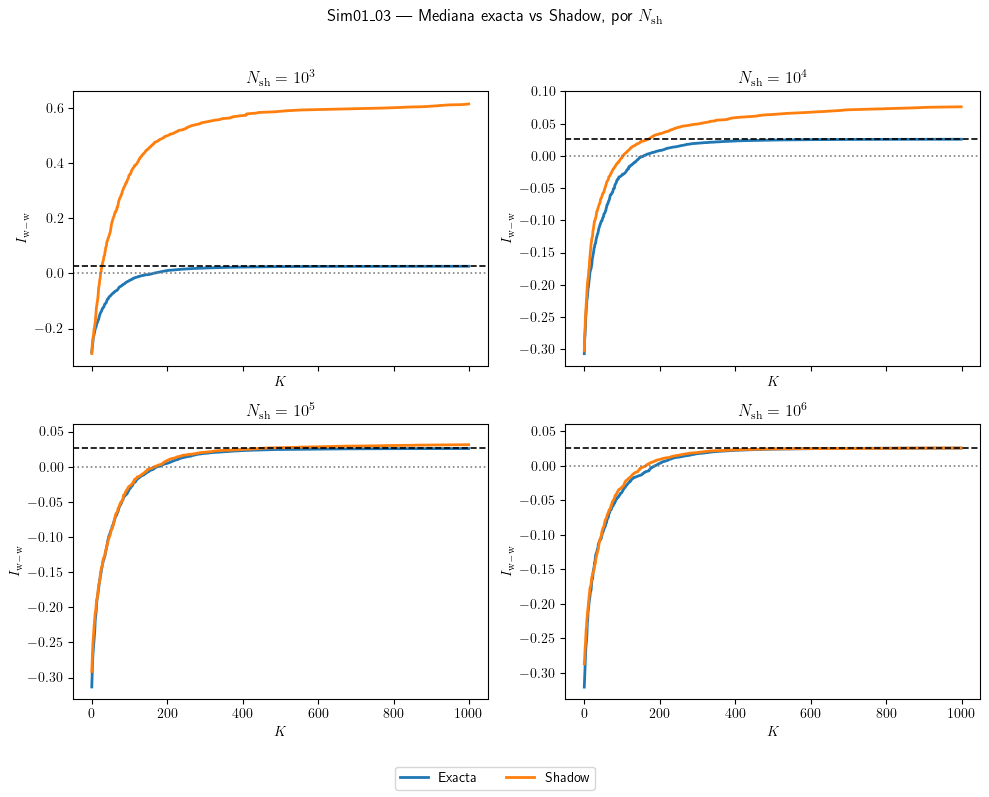

In [32]:
valor_cuantico = (np.sqrt(2) - 1) / 16
limites_top = {3: None, 4: 0.1, 5: 0.06, 6: 0.06}

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=False)
axes = axes.reshape(-1)

for ax, exponente in zip(axes, [3, 4, 5, 6]):
    ruta = f"Simulacion_01/Sim01_03_N1e{exponente}.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exacta")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponente}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

    if limites_top[exponente] is not None:
        ax.set_ylim(top=limites_top[exponente])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4)
fig.suptitle(r"Sim01\_03 --- Mediana exacta vs Shadow, por $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig("Simulacion_01/Sim01_03_ex_vs_shadow.pdf")
plt.show()

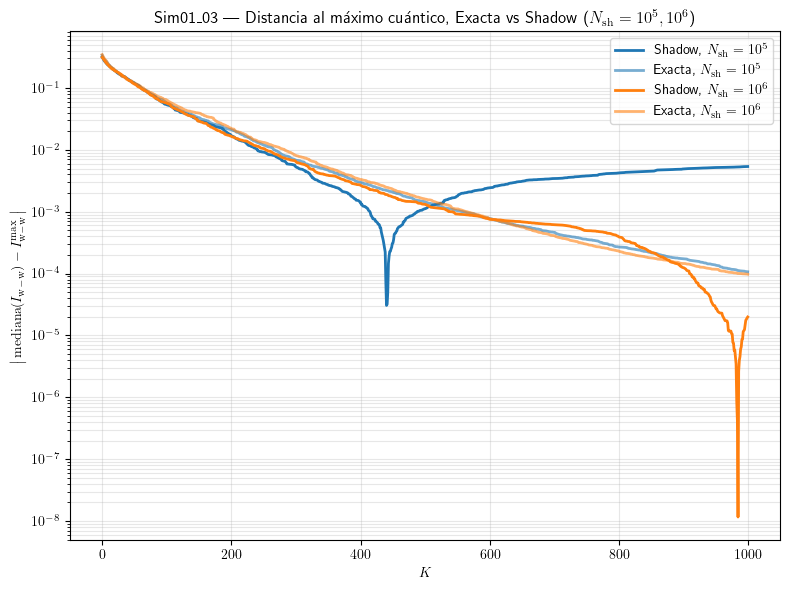

In [34]:
piso = 1e-12
valor_cuantico = (np.sqrt(2) - 1) / 16

plt.figure(figsize=(8, 6))

for exponente in [5, 6]:
    ruta = f"Simulacion_01/Sim01_03_N1e{exponente}.npz"
    Data = np.load(ruta)
    median_sh, median_ex = Data['median_sh'], Data['median_ex']

    dist_sh = np.clip(np.abs(median_sh - valor_cuantico), piso, None)
    dist_ex = np.clip(np.abs(median_ex - valor_cuantico), piso, None)

    it = np.arange(len(dist_sh))  # eje horizontal normal, empieza en 0

    linea, = plt.plot(it, dist_sh, linewidth=2,
                       label=rf"Shadow, $N_{{\rm sh}}=10^{exponente}$")
    plt.plot(it, dist_ex, linewidth=2, alpha=0.6, color=linea.get_color(),
              label=rf"Exacta, $N_{{\rm sh}}=10^{exponente}$")

plt.yscale('log')
plt.xlabel(r"$K$")
plt.ylabel(r"$\left|\,\mathrm{mediana}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")
plt.title(r"Sim01\_03 --- Distancia al máximo cuántico, Exacta vs Shadow ($N_{\rm sh}=10^5,10^6$)")
plt.legend(loc='upper right')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_03_distancia_cuantico.pdf")
plt.show()

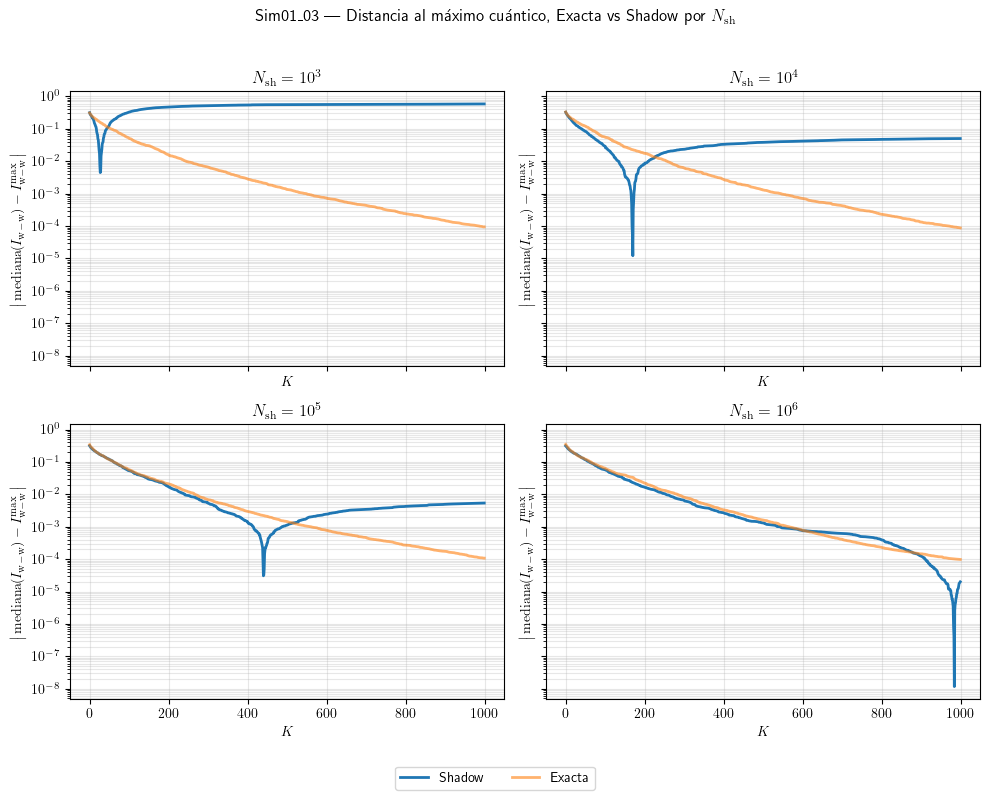

In [36]:
piso = 1e-12
valor_cuantico = (np.sqrt(2) - 1) / 16

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponente in zip(axes, [3, 4, 5, 6]):
    ruta = f"Simulacion_01/Sim01_03_N1e{exponente}.npz"
    Data = np.load(ruta)
    median_sh, median_ex = Data['median_sh'], Data['median_ex']

    dist_sh = np.clip(np.abs(median_sh - valor_cuantico), piso, None)
    dist_ex = np.clip(np.abs(median_ex - valor_cuantico), piso, None)
    it = np.arange(len(dist_sh))

    ax.plot(it, dist_sh, linewidth=2, label="Shadow")
    ax.plot(it, dist_ex, linewidth=2, alpha=0.6, label="Exacta")
    ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both')
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponente}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$\left|\,\mathrm{mediana}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
fig.suptitle(r"Sim01\_03 --- Distancia al máximo cuántico, Exacta vs Shadow por $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig("Simulacion_01/Sim01_03_distancia_cuantico_4paneles.pdf")
plt.show()

## Simulación 01_04 — Exacta, Shadow–Exacta y Full Shadow, barrido en $N_{\rm sh}$

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro                            | Valor                                                                                                               |
| ------------------------------------ | ------------------------------------------------------------------------------------------------------------------- |
| Estado (tres fuentes)                | Estado maximalmente entrelazado, singlete $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, fijo, sin parámetro libre |
| $N_{\rm sh}$ (mediciones por sombra) | ${10^3,\ 10^4,\ 10^5,\ 10^6}$, con una nueva sombra en cada repetición                                              |
| `N_rep`                              | 100 para el bloque Exacta y 100 para el bloque guiado por Shadow                                                    |
| $N_{\rm it}$ (iteraciones de CSPSA)  | 1000                                                                                                                |
| `gains`                              | `[3, 0, 0.1, 0.602, 0.101]`                                                                                         |
| Optimizador                          | CSPSA (`minimize=False`, maximización)                                                                              |
| Evaluaciones                         | Exacta; Shadow–Exacta; Full Shadow                                                                                  |

**Descripción:** esta simulación reemplaza a Sim01_03 y considera dos bloques de optimización.

En el bloque Exacta, CSPSA utiliza el funcional exacto tanto para estimar el gradiente como para registrar el valor alcanzado.

En el segundo bloque, CSPSA estima el gradiente mediante Classical Shadows. Sobre la misma trayectoria se registran dos valores después de cada iteración:

* **Shadow–Exacta:** el gradiente se estima mediante Classical Shadows, pero el funcional alcanzado se evalúa exactamente.
* **Full Shadow:** tanto la estimación del gradiente como la evaluación del funcional se realizan mediante Classical Shadows.

Por lo tanto, Shadow–Exacta y Full Shadow corresponden a los mismos puntos de optimización y pueden compararse directamente. La evaluación exacta de Shadow–Exacta tiene únicamente un propósito diagnóstico y no interviene en las actualizaciones de CSPSA.

Para cada valor de $N_{\rm sh}$ se ejecutan $2\times N_{\rm rep}$ optimizaciones: $N_{\rm rep}$ exactas y $N_{\rm rep}$ guiadas por Shadow.

**Convención de nombres:** los valores de $N_{\rm sh}$ se escriben en notación exponencial corta: `N1e3`, `N1e4`, `N1e5` y `N1e6`.

**Archivos generados:** `Simulacion_01/Sim01_04_N1e3.npz`, `Simulacion_01/Sim01_04_N1e4.npz`, `Simulacion_01/Sim01_04_N1e5.npz` y `Simulacion_01/Sim01_04_N1e6.npz`.

Cada archivo contiene:

* `Out_ex`: optimización Exacta.
* `Out_mix`: evaluación Shadow–Exacta.
* `Out_sh`: evaluación Full Shadow.

Los arreglos tienen dimensiones `N_rep` $\times$ $N_{\rm it}$. También se almacenan la media, la mediana y los cuartiles primero y tercero por iteración, utilizando los sufijos `_ex`, `_mix` y `_sh`.



In [52]:
def run_triple_N_grid(Rho, valores_N_sh, prefijo, carpeta="Simulacion_01",
                       N_rep=100, max_iter=1000, n_jobs=-6):
    """
    Para cada valor de N_sh, corre dos bloques de N_rep repeticiones:
      - Out_ex: guiada y evaluada por out_fun (exacta completa).
      - Out_mix y Out_sh: obtenidas sobre la misma trayectoria guiada
        por obj_fun. Out_mix registra la evaluación exacta y Out_sh
        registra la evaluación mediante Classical Shadows.
    """
    resultados = {}
    for N_sh in valores_N_sh:
        exponente = round(np.log10(N_sh))
        print(f"=== {prefijo}, N_sh = 1e{exponente} ===")

        def run_one_exacto(idx):
            np.random.seed()
            obj_fun_exacto = lambda Z: out_fun(Z, Rho)
            Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
            results = cspsa.minimize(obj_fun_exacto, Z_in3, max_iter,
                                      postprocessing=complex2unitary,
                                      output_function=obj_fun_exacto)
            return results.fun

        def run_one_shadow(idx):
            np.random.seed()
            enhanced_shadows, Rho_hat = create_shadow(Rho, N_sh)
            obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
            obj_fun_exacto = lambda Z: out_fun(Z, Rho)

            def output_dual(Z):
                return obj_fun_exacto(Z), obj_fun_shad(Z)

            Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
            results = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                      postprocessing=complex2unitary,
                                      output_function=output_dual)
            return np.asarray(results.fun)

        Out_ex = np.array(Parallel(n_jobs=n_jobs)(
            delayed(run_one_exacto)(idx) for idx in range(N_rep)
        ))

        Out_dual = np.array(Parallel(n_jobs=n_jobs)(
            delayed(run_one_shadow)(idx) for idx in range(N_rep)
        ))

        Out_mix = Out_dual[:, :, 0]
        Out_sh = Out_dual[:, :, 1]

        os.makedirs(carpeta, exist_ok=True)
        nombre_archivo = f"{prefijo}_N1e{exponente}.npz"
        ruta = os.path.join(carpeta, nombre_archivo)

        np.savez(ruta,
                 Out_ex=Out_ex, Out_mix=Out_mix, Out_sh=Out_sh,
                 mean_ex=Out_ex.mean(axis=0), median_ex=np.median(Out_ex, axis=0),
                 q1_ex=np.percentile(Out_ex, 25, axis=0), q3_ex=np.percentile(Out_ex, 75, axis=0),
                 mean_mix=Out_mix.mean(axis=0), median_mix=np.median(Out_mix, axis=0),
                 q1_mix=np.percentile(Out_mix, 25, axis=0), q3_mix=np.percentile(Out_mix, 75, axis=0),
                 mean_sh=Out_sh.mean(axis=0), median_sh=np.median(Out_sh, axis=0),
                 q1_sh=np.percentile(Out_sh, 25, axis=0), q3_sh=np.percentile(Out_sh, 75, axis=0),
                 N_rep=N_rep, N_it=max_iter, N_sh=N_sh)

        print(f"  Guardado: {ruta}")
        resultados[N_sh] = (Out_ex, Out_mix, Out_sh)

    return resultados

## Simulación 01_04 — Ejecución

Corre el barrido en $N_{\rm sh}\in\{10^3,10^4,10^5,10^6\}$ sobre el
estado maximalmente entrelazado, usando `run_triple_N_grid`.

In [5]:
valores_N_sh = [1e3, 1e4, 1e5, 1e6]

#resultados_sim01_04 = run_triple_N_grid(
#    Rho_max, valores_N_sh, "Sim01_04", carpeta="Simulacion_01"
#)

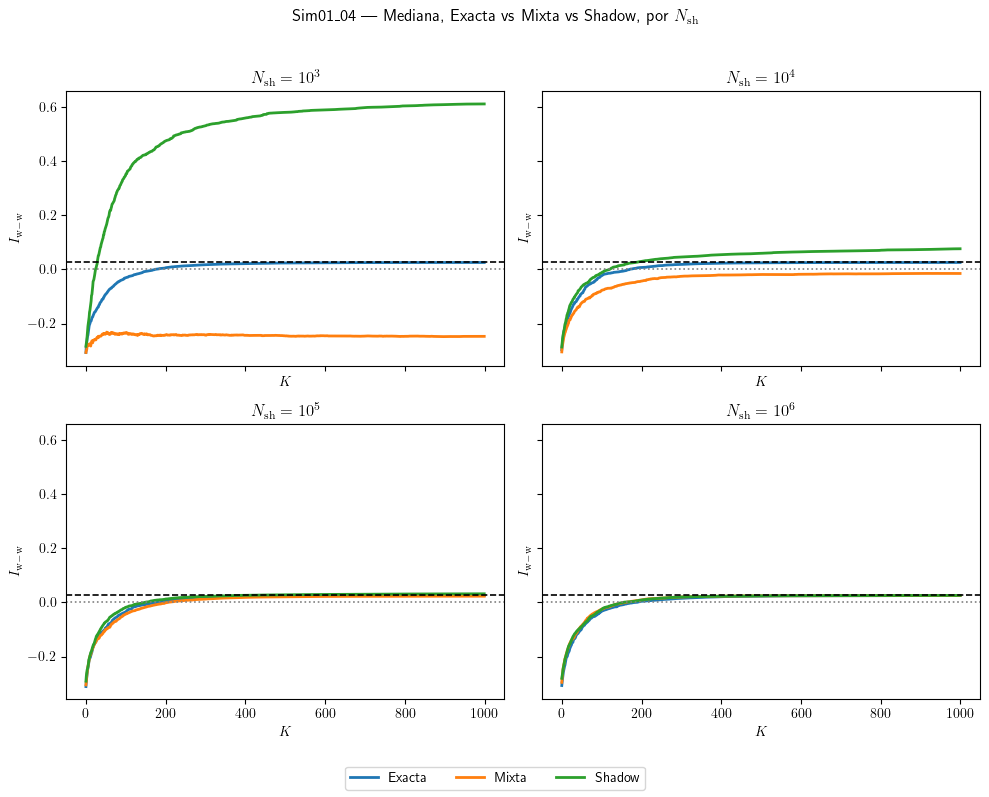

In [44]:
valor_cuantico = (np.sqrt(2) - 1) / 16

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponente in zip(axes, [3, 4, 5, 6]):
    ruta = f"Simulacion_01/Sim01_04_N1e{exponente}.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exacta")
    ax.plot(it, Data['median_mix'], linewidth=2, label="Mixta")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponente}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim01\_04 --- Mediana, Exacta vs Mixta vs Shadow, por $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig("Simulacion_01/Sim01_04_triple.pdf")
plt.show()

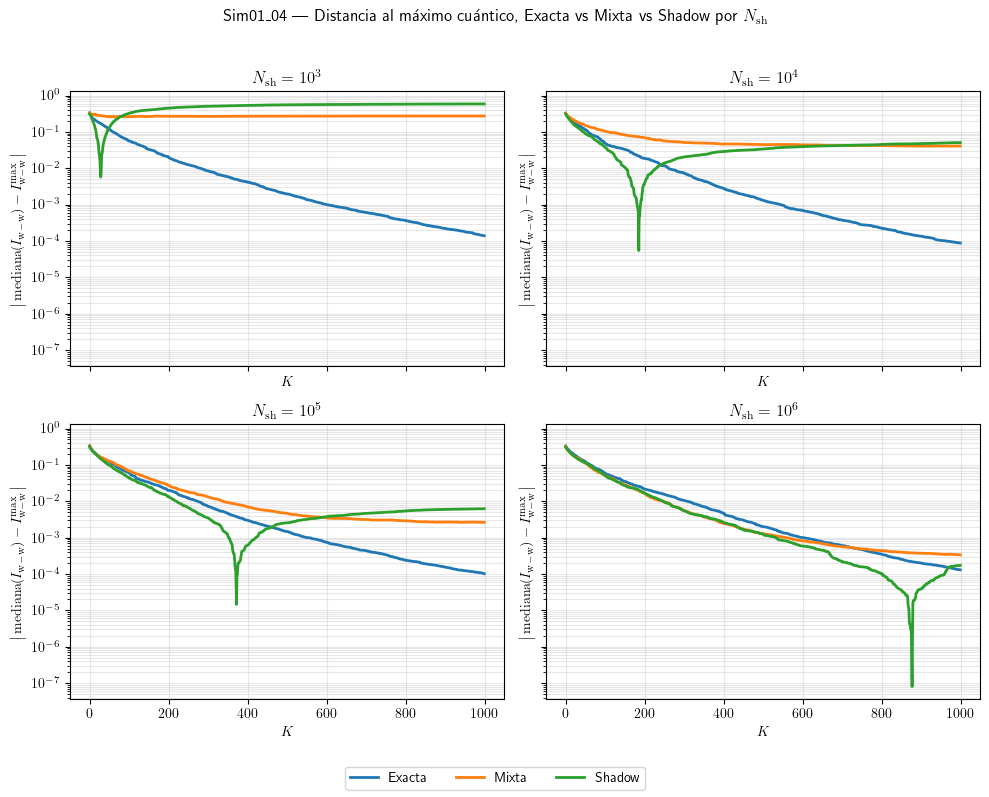

In [45]:
piso = 1e-12
valor_cuantico = (np.sqrt(2) - 1) / 16

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponente in zip(axes, [3, 4, 5, 6]):
    ruta = f"Simulacion_01/Sim01_04_N1e{exponente}.npz"
    Data = np.load(ruta)
    median_ex, median_mix, median_sh = Data['median_ex'], Data['median_mix'], Data['median_sh']

    dist_ex = np.clip(np.abs(median_ex - valor_cuantico), piso, None)
    dist_mix = np.clip(np.abs(median_mix - valor_cuantico), piso, None)
    dist_sh = np.clip(np.abs(median_sh - valor_cuantico), piso, None)
    it = np.arange(len(dist_ex))

    ax.plot(it, dist_ex, linewidth=2, label="Exacta")
    ax.plot(it, dist_mix, linewidth=2, label="Mixta")
    ax.plot(it, dist_sh, linewidth=2, label="Shadow")
    ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both')
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponente}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$\left|\,\mathrm{mediana}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim01\_04 --- Distancia al máximo cuántico, Exacta vs Mixta vs Shadow por $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig("Simulacion_01/Sim01_04_distancia_cuantico.pdf")
plt.show()

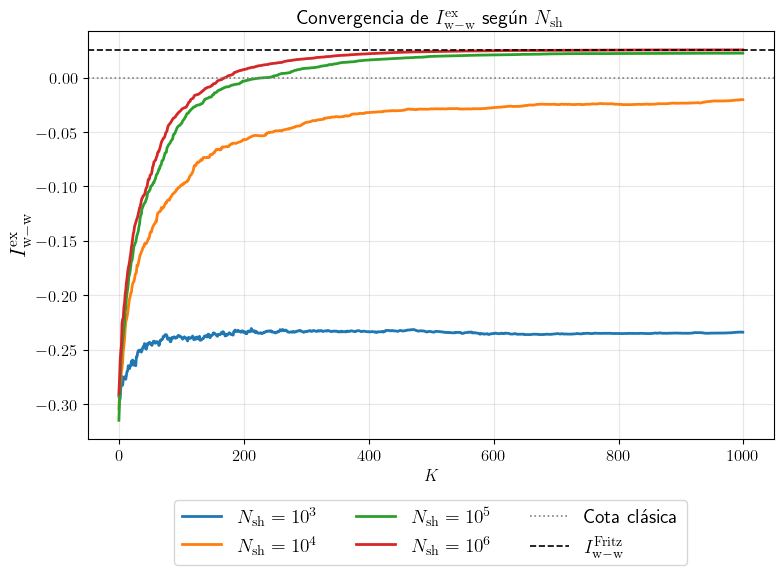

In [12]:
I_fritz = (np.sqrt(2) - 1) / 16

plt.rcParams.update({"font.size": 12, "axes.titlesize": "large", "axes.labelsize": "medium", "xtick.labelsize": "medium", "ytick.labelsize": "medium", "legend.fontsize": "medium"})

plt.figure(figsize=(8, 6))

for exponente in [3, 4, 5, 6]:
    ruta = f"Simulacion_01/Sim01_04_N1e{exponente}.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data["median_mix"]))
    plt.plot(it, Data["median_mix"], linewidth=2, label=rf"$N_{{\rm sh}}=10^{exponente}$")

plt.axhline(0, color="gray", linestyle=":", linewidth=1.2, label="Cota clásica")
plt.axhline(I_fritz, color="black", linestyle="--", linewidth=1.2, label=r"$I_{\rm w-w}^{\rm Fritz}$")

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}^{\rm ex}$", fontsize=16)
plt.title(r"Convergencia de $I_{\rm w-w}^{\rm ex}$ según $N_{\rm sh}$")

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, borderaxespad=0, fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Simulacion_01/Sim01_04_mixta_comparacion.pdf")
plt.show()

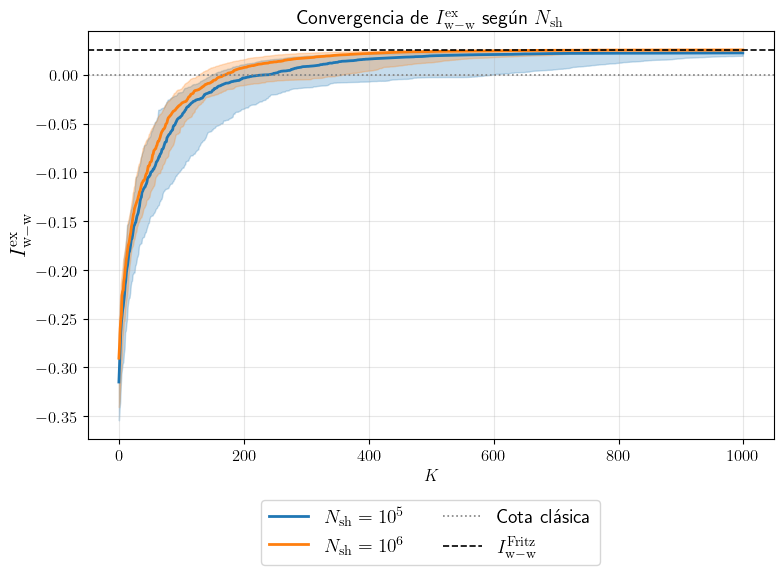

In [14]:
I_fritz = (np.sqrt(2) - 1) / 16

plt.rcParams.update({"font.size": 12, "axes.titlesize": "large", "axes.labelsize": "medium", "xtick.labelsize": "medium", "ytick.labelsize": "medium", "legend.fontsize": "medium"})

plt.figure(figsize=(8, 6))

for exponente in [5, 6]:
    ruta = f"Simulacion_01/Sim01_04_N1e{exponente}.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data["median_mix"]))

    linea, = plt.plot(it, Data["median_mix"], linewidth=2, label=rf"$N_{{\rm sh}}=10^{exponente}$")
    plt.fill_between(it, Data["q1_mix"], Data["q3_mix"], color=linea.get_color(), alpha=0.25)

plt.axhline(0, color="gray", linestyle=":", linewidth=1.2, label="Cota clásica")
plt.axhline(I_fritz, color="black", linestyle="--", linewidth=1.2, label=r"$I_{\rm w-w}^{\rm Fritz}$")

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}^{\rm ex}$", fontsize=16)
plt.title(r"Convergencia de $I_{\rm w-w}^{\rm ex}$ según $N_{\rm sh}$")

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, borderaxespad=0, fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Simulacion_01/Sim01_04_mixta_comparacion_N1e5_N1e6.pdf")
plt.show()

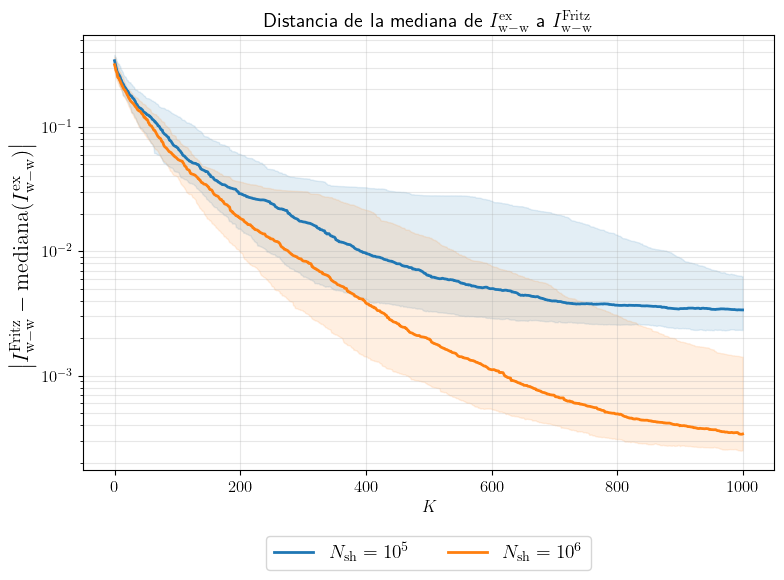

In [17]:
I_fritz = (np.sqrt(2) - 1) / 16
piso = 1e-12

plt.figure(figsize=(8, 6))

for exponente in [5, 6]:
    ruta = f"Simulacion_01/Sim01_04_N1e{exponente}.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data["median_mix"]))

    distancia = np.clip(np.abs(I_fritz - Data["median_mix"]), piso, None)
    distancia_q1 = np.clip(np.abs(I_fritz - Data["q1_mix"]), piso, None)
    distancia_q3 = np.clip(np.abs(I_fritz - Data["q3_mix"]), piso, None)

    limite_inferior = np.minimum(distancia_q1, distancia_q3)
    limite_superior = np.maximum(distancia_q1, distancia_q3)

    linea, = plt.plot(it, distancia, linewidth=2, label=rf"$N_{{\rm sh}}=10^{exponente}$")
    plt.fill_between(it, limite_inferior, limite_superior, color=linea.get_color(), alpha=0.12)

plt.yscale("log")
plt.xlabel(r"$K$")
plt.ylabel(r"$\left|I_{\rm w-w}^{\rm Fritz}-\mathrm{mediana}(I_{\rm w-w}^{\rm ex})\right|$", fontsize=16)
plt.title(r"Distancia de la mediana de $I_{\rm w-w}^{\rm ex}$ a $I_{\rm w-w}^{\rm Fritz}$")

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, borderaxespad=0, fontsize=14)
plt.grid(alpha=0.3, which="both")
plt.tight_layout()

plt.savefig("Simulacion_01/Sim01_04_mixta_distancia_N1e5_N1e6.pdf")
plt.show()

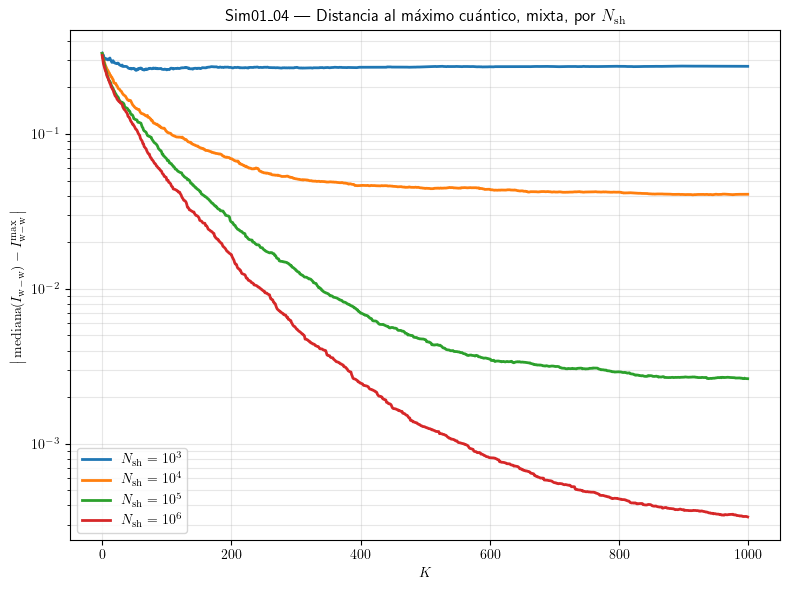

In [48]:
piso = 1e-12
valor_cuantico = (np.sqrt(2) - 1) / 16

plt.figure(figsize=(8, 6))

for exponente in [3, 4, 5, 6]:
    ruta = f"Simulacion_01/Sim01_04_N1e{exponente}.npz"
    Data = np.load(ruta)
    median_mix = Data['median_mix']

    dist_mix = np.clip(np.abs(median_mix - valor_cuantico), piso, None)
    it = np.arange(len(dist_mix))

    plt.plot(it, dist_mix, linewidth=2, label=rf"$N_{{\rm sh}}=10^{exponente}$")

plt.yscale('log')
plt.xlabel(r"$K$")
plt.ylabel(r"$\left|\,\mathrm{mediana}(I_{\rm w-w}) - I_{\rm w-w}^{\max}\,\right|$")
plt.title(r"Sim01\_04 --- Distancia al máximo cuántico, mixta, por $N_{\rm sh}$")
plt.legend(loc='lower left')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_04_mixta_distancia.pdf")
plt.show()

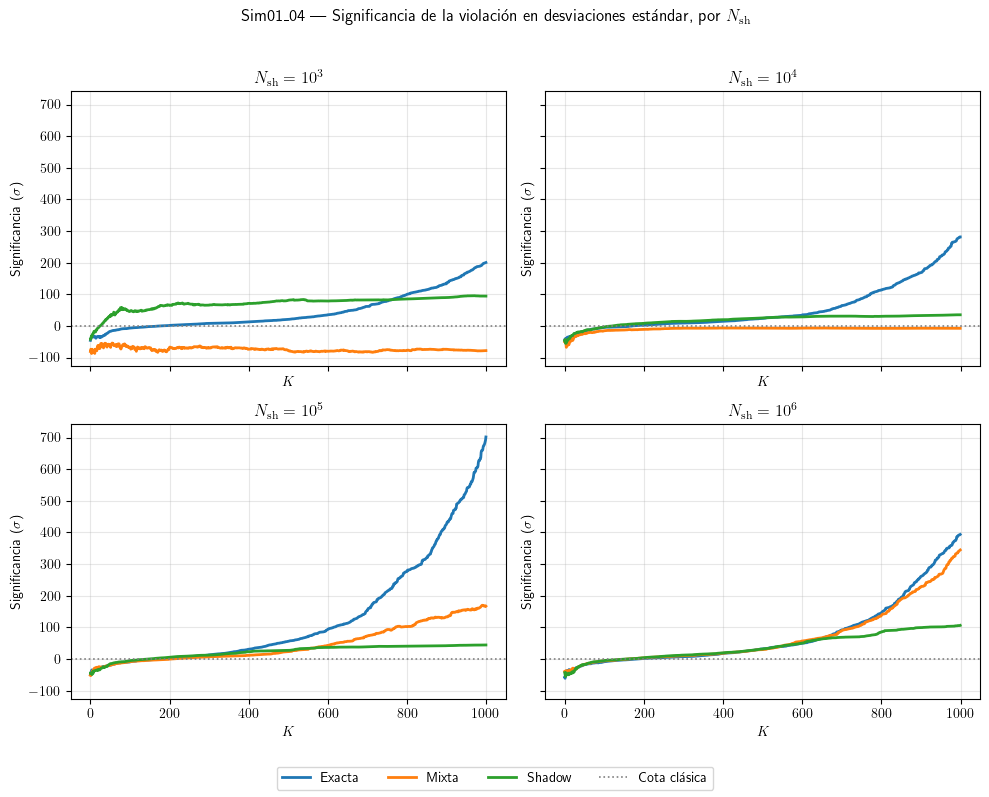

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for ax, exponente in zip(axes, [3, 4, 5, 6]):
    ruta = f"Simulacion_01/Sim01_04_N1e{exponente}.npz"
    Data = np.load(ruta)
    N_rep = int(Data['N_rep'])

    for med_key, q1_key, q3_key, label in [
        ('median_ex', 'q1_ex', 'q3_ex', "Exacta"),
        ('median_mix', 'q1_mix', 'q3_mix', "Mixta"),
        ('median_sh', 'q1_sh', 'q3_sh', "Shadow"),
    ]:
        mediana = Data[med_key]
        iqr = Data[q3_key] - Data[q1_key]
        # error estandar de la mediana, estimado a partir del IQR,
        # asumiendo aproximadamente normalidad (IQR = 1.35*sigma)
        sem = np.clip((iqr / 1.35) / np.sqrt(N_rep), 1e-12, None)
        sigma = mediana / sem

        it = np.arange(len(sigma))
        ax.plot(it, sigma, linewidth=2, label=label)

    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2, label="Cota clásica")
    ax.set_title(rf"$N_{{\rm sh}}=10^{exponente}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"Significancia ($\sigma$)")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4)
fig.suptitle(r"Sim01\_04 --- Significancia de la violación en desviaciones estándar, por $N_{\rm sh}$")
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig("Simulacion_01/Sim01_04_significancia.pdf")
plt.show()